# Simple Logistic Regression

In [1]:
import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GroupKFold
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    roc_auc_score
)

In [2]:
def run_logreg_groupcv(X, y, groups, name, n_splits=5):
    gkf = GroupKFold(n_splits=n_splits)

    rows = []

    for fold, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups)):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        pipe = Pipeline([
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(
                penalty="l2",
                solver="liblinear",
                max_iter=1000,
                class_weight="balanced",
                random_state=42
            ))
        ])

        pipe.fit(X_train, y_train)
        y_pred = pipe.predict(X_test)
        y_prob = pipe.predict_proba(X_test)[:, 1]

        rows.append({
            "feature_set": name,
            "fold": fold,
            "accuracy": accuracy_score(y_test, y_pred),
            "balanced_accuracy": balanced_accuracy_score(y_test, y_pred),
            "roc_auc": roc_auc_score(y_test, y_prob)
        })

    return pd.DataFrame(rows)

In [14]:
import pandas as pd
from pathlib import Path

FEATURE_DIR = Path("../data/features_participant")

X_pupil_only = pd.read_csv(FEATURE_DIR / "X_pupil_only.csv")
X_gaze_only  = pd.read_csv(FEATURE_DIR / "X_gaze_only.csv")
X_combined   = pd.read_csv(FEATURE_DIR / "X_combined.csv")
y            = pd.read_csv(FEATURE_DIR / "y.csv")["label"]

# Load participant IDs from your master participant-level feature file
ids_df = pd.read_csv("../data/X_pupil_participant.csv", usecols=["participant"])
groups = ids_df["participant"].to_numpy()

# sanity check alignment
assert len(groups) == len(y) == len(X_pupil_only) == len(X_gaze_only) == len(X_combined)

print("OK:", len(groups), "participants")

OK: 57 participants


In [16]:
results_pupil = run_logreg_groupcv(
    X_pupil_only, y, groups, name="pupil_only"
)

results_gaze = run_logreg_groupcv(
    X_gaze_only, y, groups, name="gaze_only"
)

results_combined = run_logreg_groupcv(
    X_combined, y, groups, name="combined"
)

results_all = pd.concat(
    [results_pupil, results_gaze, results_combined],
    ignore_index=True
)

In [17]:
summary = (
    results_all
    .groupby("feature_set")
    .agg(
        acc_mean=("accuracy", "mean"),
        acc_sd=("accuracy", "std"),
        bal_acc_mean=("balanced_accuracy", "mean"),
        bal_acc_sd=("balanced_accuracy", "std"),
        auc_mean=("roc_auc", "mean"),
        auc_sd=("roc_auc", "std"),
    )
    .round(3)
    .reset_index()
)

summary

,feature_set,acc_mean,acc_sd,bal_acc_mean,bal_acc_sd,auc_mean,auc_sd
0,combined,0.773,0.097,0.767,0.088,0.834,0.048
1,gaze_only,0.703,0.093,0.713,0.086,0.820,0.018
2,pupil_only,0.759,0.184,0.756,0.183,0.791,0.152


“Across group-wise cross-validation, the combined gaze+pupil feature set achieved the best performance (accuracy 0.77 ± 0.10; ROC-AUC 0.83 ± 0.05), outperforming gaze-only and yielding more stable results than pupil-only.”

# L1 Logistic Regression

In [34]:
import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GroupKFold
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    roc_auc_score,
)


def run_l1_logreg_groupcv(
    X: pd.DataFrame,
    y: pd.Series,
    groups: np.ndarray,
    name: str,
    n_splits: int = 5,
    C: float = 1.0,
):
    """
    L1-regularized Logistic Regression with GroupKFold CV.
    Returns a DataFrame with per-fold metrics.
    """

    gkf = GroupKFold(n_splits=n_splits)
    rows = []

    for fold, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups)):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        pipe = Pipeline([
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(
                penalty="l1",
                solver="liblinear",
                C=C,
                class_weight="balanced",
                max_iter=500,
                random_state=42,
            ))
        ])

        pipe.fit(X_train, y_train)

        y_pred = pipe.predict(X_test)
        y_prob = pipe.predict_proba(X_test)[:, 1]

        rows.append({
            "feature_set": name,
            "fold": fold,
            "accuracy": accuracy_score(y_test, y_pred),
            "balanced_accuracy": balanced_accuracy_score(y_test, y_pred),
            "f1_macro": f1_score(y_test, y_pred, average="macro"),
            "roc_auc": roc_auc_score(y_test, y_prob),
            "n_train": len(train_idx),
            "n_test": len(test_idx),
        })

    return pd.DataFrame(rows)

In [35]:
res_l1_pupil = run_l1_logreg_groupcv(
    X_pupil_only, y, groups, name="pupil_only"
)

res_l1_gaze = run_l1_logreg_groupcv(
    X_gaze_only, y, groups, name="gaze_only"
)

res_l1_combined = run_l1_logreg_groupcv(
    X_combined, y, groups, name="combined"
)

results_l1 = pd.concat(
    [res_l1_pupil, res_l1_gaze, res_l1_combined],
    ignore_index=True
)

In [36]:
summary_l1 = (
    results_l1
    .groupby("feature_set")
    .agg(
        acc_mean=("accuracy", "mean"),
        acc_sd=("accuracy", "std"),
        bal_acc_mean=("balanced_accuracy", "mean"),
        bal_acc_sd=("balanced_accuracy", "std"),
        auc_mean=("roc_auc", "mean"),
        auc_sd=("roc_auc", "std"),
    )
    .round(3)
    .reset_index()
)

summary_l1

,feature_set,acc_mean,acc_sd,bal_acc_mean,bal_acc_sd,auc_mean,auc_sd
0,combined,0.720,0.071,0.716,0.060,0.840,0.055
1,gaze_only,0.686,0.105,0.699,0.088,0.820,0.038
2,pupil_only,0.721,0.201,0.719,0.196,0.791,0.147


In [38]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        penalty="l1",
        solver="liblinear",
        C=1.0,                 # same C as in CV
        class_weight="balanced",
        max_iter=500,
        random_state=42,
    ))
])

pipe.fit(X_combined, y)

coef = pipe.named_steps["clf"].coef_.ravel()

coef_df = (
    pd.DataFrame({
        "feature": X_combined.columns,
        "coef": coef,
        "abs_coef": np.abs(coef),
    })
    .sort_values("abs_coef", ascending=False)
    .reset_index(drop=True)
)

coef_df

,feature,coef,abs_coef
0,fix_count,1.101446,1.101446
1,mean_fix_dur_ms,1.068688,1.068688
2,vel_peak_abs,0.758297,0.758297
3,vel_mean_abs,0.719022,0.719022
4,pupil_mean,-0.416312,0.416312
5,pupil_centered_range,-0.408331,0.408331
6,pupil_range,-0.063340,0.063340
7,mean_sac_amp,0.021242,0.021242
8,pupil_centered_iqr,0.000000,0.000000
9,sac_count,0.000000,0.000000


L1 regularisation keeps only a small subset of features and sets the rest exactly to zero.
	•	Non-zero coefficients → features the model actually uses
	•	Zero coefficients → features discarded as uninformative or redundant

So this table is a feature selection result, not just weights.

Strongest contributors (highest |coef|):
	1.	fix_count (+1.10)
	2.	mean_fix_dur_ms (+1.07)

→ Gaze behaviour dominates prediction.

This means:
	•	More fixations
	•	Longer average fixation duration
are strongly associated with class membership (ASD vs TD).

⸻

The model does keep pupil features, but they are weaker than gaze:
	•	vel_peak_abs (+0.76)
	•	vel_mean_abs (+0.72)
	•	pupil_mean (−0.42)
	•	pupil_centered_range (−0.41)

Interpretation:
	•	Dynamic pupil features (velocity) matter more than static size
	•	Higher pupil variability / dilation is associated with one class, but less strongly than gaze

This aligns well with psychophysiology expectations.


# Linear SVM 

In [39]:
import numpy as np
import pandas as pd

from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupKFold
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    roc_auc_score
)

In [40]:
def run_linear_svm_groupcv(
    X: pd.DataFrame,
    y: pd.Series,
    groups: np.ndarray,
    name: str,
    n_splits: int = 5,
    C: float = 1.0
):
    """
    Linear SVM with group-aware CV.
    Returns fold-level results DataFrame.
    """

    gkf = GroupKFold(n_splits=n_splits)

    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LinearSVC(
            C=C,
            class_weight="balanced",
            max_iter=10_000,
        ))
    ])

    rows = []

    for fold, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups)):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        pipe.fit(X_train, y_train)
        y_pred = pipe.predict(X_test)

        acc = accuracy_score(y_test, y_pred)
        bal_acc = balanced_accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred, average="macro")

        rows.append({
            "feature_set": name,
            "fold": fold,
            "n_train": len(train_idx),
            "n_test": len(test_idx),
            "accuracy": acc,
            "balanced_accuracy": bal_acc,
            "f1_macro": f1,
        })

    return pd.DataFrame(rows)

In [41]:
svm_pupil = run_linear_svm_groupcv(
    X_pupil_only, y, groups, name="pupil_only"
)

svm_gaze = run_linear_svm_groupcv(
    X_gaze_only, y, groups, name="gaze_only"
)

svm_combined = run_linear_svm_groupcv(
    X_combined, y, groups, name="combined"
)

svm_results = pd.concat(
    [svm_pupil, svm_gaze, svm_combined],
    ignore_index=True
)

In [42]:
svm_summary = (
    svm_results
    .groupby("feature_set")
    .agg(
        acc_mean=("accuracy", "mean"),
        acc_sd=("accuracy", "std"),
        bal_acc_mean=("balanced_accuracy", "mean"),
        bal_acc_sd=("balanced_accuracy", "std"),
        f1_mean=("f1_macro", "mean"),
        f1_sd=("f1_macro", "std"),
    )
    .round(3)
    .reset_index()
)

svm_summary

,feature_set,acc_mean,acc_sd,bal_acc_mean,bal_acc_sd,f1_mean,f1_sd
0,combined,0.773,0.097,0.767,0.088,0.766,0.096
1,gaze_only,0.721,0.086,0.730,0.079,0.718,0.086
2,pupil_only,0.809,0.156,0.812,0.146,0.802,0.164


In [43]:
pipe.fit(X_combined, y)

coef = pipe.named_steps["clf"].coef_.ravel()

coef_df = (
    pd.DataFrame({
        "feature": X_combined.columns,
        "coef": coef,
        "abs_coef": np.abs(coef)
    })
    .sort_values("abs_coef", ascending=False)
)

coef_df

,feature,coef,abs_coef
14,fix_count,1.101446,1.101446
13,mean_fix_dur_ms,1.068688,1.068688
12,vel_peak_abs,0.758297,0.758297
11,vel_mean_abs,0.719022,0.719022
3,pupil_mean,-0.416312,0.416312
9,pupil_centered_range,-0.408331,0.408331
5,pupil_range,-0.063340,0.063340
16,mean_sac_amp,0.021242,0.021242
10,pupil_centered_iqr,0.000000,0.000000
15,sac_count,0.000000,0.000000


# XGBoost

In [46]:
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, roc_auc_score
from xgboost import XGBClassifier

def run_xgb_groupcv(X: pd.DataFrame, y: pd.Series, groups: np.ndarray, name="xgb", n_splits=5, seed=42):
    X = X.copy()
    y = pd.Series(y).astype(str)

    # --- encode labels to 0/1 (or 0..K-1) ---
    le = LabelEncoder()
    y_enc = le.fit_transform(y)          # ASD/TD -> 0/1 (alphabetical)
    is_binary = (len(le.classes_) == 2)

    cv = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=seed)

    rows = []
    for fold, (tr, te) in enumerate(cv.split(X, y_enc, groups)):
        X_tr, X_te = X.iloc[tr], X.iloc[te]
        y_tr, y_te = y_enc[tr], y_enc[te]

        clf = XGBClassifier(
            n_estimators=300,
            max_depth=2,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_lambda=2.0,
            reg_alpha=0.0,
            min_child_weight=2,
            gamma=0.0,
            objective="binary:logistic" if is_binary else "multi:softprob",
            eval_metric="logloss",
            random_state=seed,
            n_jobs=-1,
            missing=np.nan,
        )

        clf.fit(X_tr, y_tr)

        y_pred = clf.predict(X_te)

        out = {
            "feature_set": name,
            "fold": fold,
            "n_train": len(tr),
            "n_test": len(te),
            "accuracy": accuracy_score(y_te, y_pred),
            "balanced_accuracy": balanced_accuracy_score(y_te, y_pred),
            "f1_macro": f1_score(y_te, y_pred, average="macro"),
            "roc_auc": np.nan,
        }

        if is_binary:
            y_proba = clf.predict_proba(X_te)[:, 1]
            out["roc_auc"] = roc_auc_score(y_te, y_proba)

        rows.append(out)

    results = pd.DataFrame(rows)
    print("Label mapping:", dict(zip(le.classes_, le.transform(le.classes_))))
    return results

In [52]:
results_xgb_pupil = run_xgb_groupcv(X_pupil_only, y, groups, name="pupil_only_xgb")
results_xgb_gaze  = run_xgb_groupcv(X_gaze_only,  y, groups, name="gaze_only_xgb")
results_xgb_comb  = run_xgb_groupcv(X_combined,   y, groups, name="combined_xgb")

results_xgb_all = pd.concat([results_xgb_pupil, results_xgb_gaze, results_xgb_comb], ignore_index=True)

summary_xgb = (results_xgb_all
               .groupby("feature_set")[["accuracy","balanced_accuracy","f1_macro","roc_auc"]]
               .agg(["mean","std"])
               .round(3))
summary_xgb

Label mapping: {'ASD': np.int64(0), 'TD': np.int64(1)}
Label mapping: {'ASD': np.int64(0), 'TD': np.int64(1)}
Label mapping: {'ASD': np.int64(0), 'TD': np.int64(1)}


accuracy        balanced_accuracy        f1_macro         \
                   mean    std              mean    std     mean    std   
feature_set                                                               
combined_xgb      0.788  0.056             0.796  0.067    0.786  0.058   
gaze_only_xgb     0.735  0.095             0.743  0.099    0.733  0.096   
pupil_only_xgb    0.545  0.107             0.555  0.088    0.533  0.092   

               roc_auc         
                  mean    std  
feature_set                    
combined_xgb     0.820  0.109  
gaze_only_xgb    0.822  0.088  
pupil_only_xgb   0.601  0.132

<Figure size 640x480 with 0 Axes>

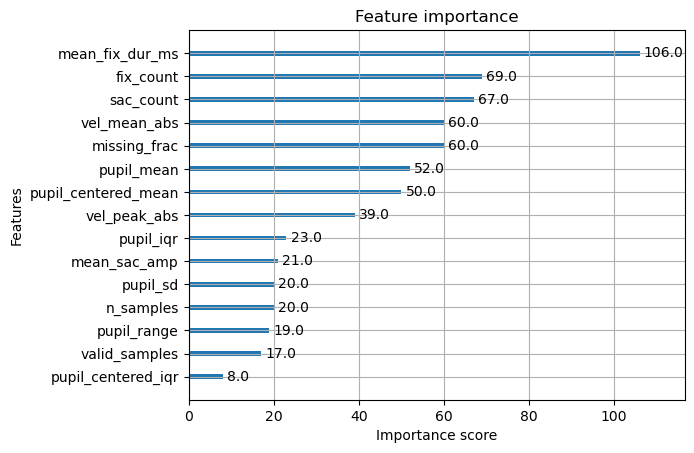

In [ ]:
from xgboost import plot_importance
import matplotlib.pyplot as plt

clf = XGBClassifier(
    n_estimators=300, max_depth=2, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, reg_lambda=2.0,
    eval_metric="logloss", random_state=42, n_jobs=-1, missing=np.nan
)
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_enc = le.fit_transform(y.astype(str))

clf.fit(X_combined, y_enc)

plt.figure()
plot_importance(clf, max_num_features=15)
plt.show()

In [63]:
summary["model"] = "Logistic Regression"
summary_l1["model"]  = "L1 Logistic Regression"
svm_summary["model"]    = "Linear SVM"
summary_xgb["model"]    = "XGBoost"

In [ ]:
summary_all = pd.concat(
    [summary, summary_l1, svm_summary],
    ignore_index=True
)

summary_all = summary_all[
    [
        "model",
        "feature_set",
        "acc_mean", "acc_sd",
        "bal_acc_mean", "bal_acc_sd",
        "f1_mean", "f1_sd",
        "auc_mean", "auc_sd",
    ]
].round(3)

summary_all["feature_set"] = summary_all["feature_set"].replace({
    "pupil_only": "Pupil",
    "gaze_only": "Gaze",
    "combined": "Pupil + Gaze",
})

summary_all

,model,feature_set,acc_mean,acc_sd,bal_acc_mean,bal_acc_sd,f1_mean,f1_sd,auc_mean,auc_sd
0,Logistic Regression,Pupil + Gaze,0.773,0.097,0.767,0.088,NaN,NaN,0.834,0.048
1,Logistic Regression,Gaze,0.703,0.093,0.713,0.086,NaN,NaN,0.820,0.018
2,Logistic Regression,Pupil,0.759,0.184,0.756,0.183,NaN,NaN,0.791,0.152
3,L1 Logistic Regression,Pupil + Gaze,0.720,0.071,0.716,0.060,NaN,NaN,0.840,0.055
4,L1 Logistic Regression,Gaze,0.686,0.105,0.699,0.088,NaN,NaN,0.820,0.038
5,L1 Logistic Regression,Pupil,0.721,0.201,0.719,0.196,NaN,NaN,0.791,0.147
6,Linear SVM,Pupil + Gaze,0.773,0.097,0.767,0.088,0.766,0.096,NaN,NaN
7,Linear SVM,Gaze,0.721,0.086,0.730,0.079,0.718,0.086,NaN,NaN
8,Linear SVM,Pupil,0.809,0.156,0.812,0.146,0.802,0.164,NaN,NaN
